# 🏥 MediAssist: Healthcare LLM Fine-Tuning with Gemma 2 2B + TensorFlow

[![Run on Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/)

**Fine-tuning Google Gemma 2 2B Instruct on medical Q&A using LoRA + TensorFlow/Keras on Kaggle P100.**

| Component | Detail |
|-----------|--------|
| Base Model | Gemma 2 2B Instruct (`gemma2_instruct_2b_en`) |
| Framework | TensorFlow 2.x + Keras 3 + keras-hub |
| PEFT | LoRA (rank 4/8/16) via `backbone.enable_lora()` |
| Dataset | `medalpaca/medical_meadow_medical_flashcards` |
| Accelerator | Kaggle P100 (16 GB VRAM, 9-hour sessions) |
| Output | Saved to `/kaggle/working/` — downloadable from Output tab |


---
## 📦 Section 1: Environment Setup

### Kaggle setup (one-time, before running the notebook)

**Step 1 — Enable the P100 GPU**
In the Kaggle notebook editor: *Settings (right panel) → Accelerator → GPU P100*

**Step 2 — Add Gemma 2 2B as a model input (avoids the 5 GB download every run)**
1. Click *Add Input* (top right) → *Models* tab
2. Search **Gemma 2**
3. Select **Gemma 2** by Google → Framework: **Keras** → Variation: **gemma2_instruct_2b_en** → Version **2**
4. Click *Add* — the model will appear under `/kaggle/input/gemma-2/`

> **Note:** You must accept the Gemma licence on Kaggle once at  
> https://www.kaggle.com/models/google/gemma-2 before the model input will work.

**Step 3 — Enable Internet access**
Settings → *Internet → On* (required for HuggingFace dataset download)

**Step 4 — Run all cells top-to-bottom**
All outputs save to `/kaggle/working/mediassist_gemma2/` and are downloadable from the *Output* tab.


In [1]:
# ============================================================
# 1.1 Install / upgrade required packages
# ============================================================
# Kaggle notebooks have TensorFlow, Keras, and most ML packages
# pre-installed. We only need to install/upgrade a few extras.
# This takes ~60 seconds on first run.

# keras-hub: ships Gemma 2 weights natively via Kaggle model hub
!pip install -q keras-hub
!pip install -q keras==3.7.0

# HuggingFace datasets — loads medical flashcards (needs Internet ON)
!pip install -q datasets==2.19.0

# Evaluation metrics
!pip install -q rouge-score nltk


print('All packages ready.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 13.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
All packages ready.


### What was installed

| Package | Version / Note | Purpose |
|---------|---------------|--------|
| `keras-hub` | latest | Loads the Gemma 2 2B preset natively from the Kaggle Model Hub — no manual weight download required |
| `keras` | 3.7.0 | Pinned for compatibility with the keras-hub Gemma 2 preset |
| `datasets` | 2.19.0 | HuggingFace Datasets — streams `medalpaca/medical_meadow_medical_flashcards` directly from the Hub |
| `rouge-score` | latest | Computes ROUGE-1/2/L for evaluation |
| `nltk` | latest | Provides BLEU score computation |

> **Why these exact versions?** keras-hub requires Keras ≥ 3.x (multi-backend) and is incompatible with the legacy `keras` 2.x that ships with older Kaggle/Colab images. Pinning `keras==3.7.0` avoids silent API drift.
> The two pip dependency warnings (bigframes, gcsfs) are safe to ignore — they do not affect any package used in this notebook.

In [2]:
# ============================================================
# 1.2 Kaggle Authentication
# ============================================================
import os
from kaggle_secrets import UserSecretsClient

# Read from Kaggle Secrets panel (Settings -> Secrets)
# Make sure KAGGLE_USERNAME and KAGGLE_KEY are added and enabled there.
user_secrets = UserSecretsClient()
kaggle_user = user_secrets.get_secret("KAGGLE_USERNAME")
kaggle_key  = user_secrets.get_secret("KAGGLE_KEY")

# Write ~/.kaggle/kaggle.json so keras-hub can authenticate
import json
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)
kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
with open(kaggle_json_path, "w") as f:
    json.dump({"username": kaggle_user, "key": kaggle_key}, f)
os.chmod(kaggle_json_path, 0o600)

# Also export as env vars for keras-hub's downloader
os.environ["KAGGLE_USERNAME"] = kaggle_user
os.environ["KAGGLE_KEY"]      = kaggle_key

KAGGLE_OUTPUT = '/kaggle/working/mediassist_gemma2'
os.makedirs(KAGGLE_OUTPUT, exist_ok=True)

print(f"Auth OK — user: {kaggle_user}")
print(f"Output directory: {KAGGLE_OUTPUT}")

Auth OK — user: sengaemmanuelemmy
Output directory: /kaggle/working/mediassist_gemma2


### Authentication strategy

Kaggle Secrets (the *Settings → Secrets* panel) are used rather than hard-coding credentials in the notebook. The `UserSecretsClient` retrieves `KAGGLE_USERNAME` and `KAGGLE_KEY` at runtime and writes them to `~/.kaggle/kaggle.json` (permissions locked to `600`) while simultaneously exporting them as environment variables. This dual approach satisfies both the Kaggle CLI file convention and the environment-variable convention used by keras-hub's model downloader.

All artefacts produced during training are written to `/kaggle/working/mediassist_gemma2/` and are visible in the notebook's *Output* tab for one-click download.

In [3]:
# ============================================================
# 1.3 Verify GPU & Configure TensorFlow
# ============================================================
import tensorflow as tf
import subprocess, os
import keras

# Enable memory growth so TF doesn't pre-allocate all 16 GB upfront
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
         '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print(f'GPU detected: {result.stdout.strip()}')
    # P100 has 16 GB VRAM — enough for Gemma 2 2B float16 + LoRA
    # with comfortable headroom for batch=4 and full 256-token sequences.
else:
    print('No GPU found. Go to Settings -> Accelerator -> GPU P100 and restart.')

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')
print(f'Backend:    {keras.backend.backend()}')


2026-02-23 11:48:28.504078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771847308.685845      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771847308.745496      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771847309.197793      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771847309.197836      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771847309.197839      55 computation_placer.cc:177] computation placer alr

GPU detected: Tesla P100-PCIE-16GB, 16384 MiB, 580.105.08
TensorFlow: 2.19.0
Keras:      3.7.0
Backend:    tensorflow


### GPU & framework verification

TensorFlow memory growth is enabled before any model is loaded. Without this flag TensorFlow pre-allocates the entire 16 GB of VRAM on the P100/T4, which leaves no headroom for the Keras data pipeline buffers and causes OOM errors mid-training.

`nvidia-smi` is called programmatically to confirm the GPU model, total VRAM, and driver version — making this cell a one-stop health check before running any heavy workload.

In [4]:
# ============================================================
# Core Imports
# ============================================================

import os
import re
import time
import warnings
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Optional

warnings.filterwarnings("ignore")

import tensorflow as tf
import keras
import keras_hub

from datasets import load_dataset

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

# ── Reproducibility ───────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

# ── Global constants ──────────────────────────────────────────────────
# gemma2_instruct_2b_en is the correct keras-hub native preset for
# Gemma 2 2B Instruct. It downloads directly from Kaggle via keras-hub's
# built-in preset system.
#
# Note: Gemma 3n E2B is NOT yet supported in keras-hub —
#   - 'gemma3n_instruct_e2b_en'   → not a registered preset (ValueError)
#   - 'hf://google/gemma-3n-E2B-it' → no HF converter for gemma3n (ValueError)
#   Gemma 2 2B Instruct uses the identical <start_of_turn> template and
#   is the best currently-supported Gemma model in keras-hub.
MODEL_PRESET = "gemma2_instruct_2b_en"   # keras-hub native Kaggle preset

# Outputs persist in /kaggle/working/ for the session duration
# /kaggle/working/ persists for the session and is downloadable
OUTPUT_DIR  = "/kaggle/working/mediassist_gemma2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Kaggle P100 has 16 GB VRAM + ~16 GB RAM -- full 256-token budget is safe.
MAX_SEQ_LEN = 256
EOS_TOKEN   = "<eos>"   # Gemma 2's end-of-sequence token

print(f"✅ All imports successful")
print(f"   Model preset:     {MODEL_PRESET}")
print(f"   Output directory: {OUTPUT_DIR}")
print(f"   Logical devices:  {[d.name for d in tf.config.list_logical_devices()]}")

✅ All imports successful
   Model preset:     gemma2_instruct_2b_en
   Output directory: /kaggle/working/mediassist_gemma2
   Logical devices:  ['/device:CPU:0', '/device:GPU:0']


I0000 00:00:1771847334.883247      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


### Core library imports

All top-level imports are consolidated here so that missing packages surface immediately (before any GPU time is consumed). Key namespaces loaded:

- **`keras_hub`** — Gemma 2 model preset, tokeniser, and `CausalLMMaskedLoss`
- **`tensorflow as tf`** — data pipeline (`tf.data`), mixed precision, and the compute backend
- **`datasets`** — HuggingFace dataset loader
- **`matplotlib / seaborn`** — training curves and metric visualisations
- **`rouge_score`, `nltk`** — automated evaluation metrics
- **`re`, `html`, `unicodedata`** — text normalisation utilities used in preprocessing

---
## 📊 Section 2: Dataset Collection, Exploration & Preprocessing

### Dataset: `medalpaca/medical_meadow_medical_flashcards`

Sourced from **Anki medical flashcards** used by medical students globally. Covers anatomy, physiology, pharmacology, pathology, and clinical medicine.

**Schema:**
- `input` — Medical question / prompt
- `output` — Correct medical answer
- `instruction` — Fixed task description

In [5]:
# ============================================================
# 2.1 Load the Medical Dataset from HuggingFace Hub
# ============================================================
print("Loading medical flashcards dataset...")

raw_dataset = load_dataset(
    "medalpaca/medical_meadow_medical_flashcards",
    split="train"
)

print(f"\n📋 Dataset loaded!")
print(f"   Total samples: {len(raw_dataset):,}")
print(f"   Features:      {list(raw_dataset.features.keys())}")
print("\n🔍 Sample record:")
for key, val in raw_dataset[0].items():
    val_str = str(val)
    print(f"  [{key}]: {val_str[:200]}{'...' if len(val_str) > 200 else ''}")

Loading medical flashcards dataset...


Generating train split:   0%|          | 0/33955 [00:00<?, ? examples/s]


📋 Dataset loaded!
   Total samples: 33,955
   Features:      ['input', 'output', 'instruction']

🔍 Sample record:
  [input]: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?
  [output]: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.
  [instruction]: Answer this question truthfully


### 2.1 Dataset loading

The `medalpaca/medical_meadow_medical_flashcards` dataset is streamed directly from the HuggingFace Hub. Each sample contains a **human** field (the question / prompt) and an **ai** field (the expected answer). The dataset covers medical flashcard content across anatomy, pharmacology, pathology, physiology, and clinical medicine — making it ideal for domain-adaptation of a general-purpose LLM.

Raw dataset size: ~33 000 samples (train split only; no official val/test splits provided).

📊 Text Length Statistics (word count):
       input_len  output_len  total_len
count   33955.00    33955.00   33955.00
mean       14.56       53.50      68.06
std         5.82       48.81      49.80
min         0.00        0.00       0.00
25%        11.00       14.00      27.00
50%        14.00       22.00      41.00
75%        18.00      101.00     115.00
max        62.00      245.00     265.00


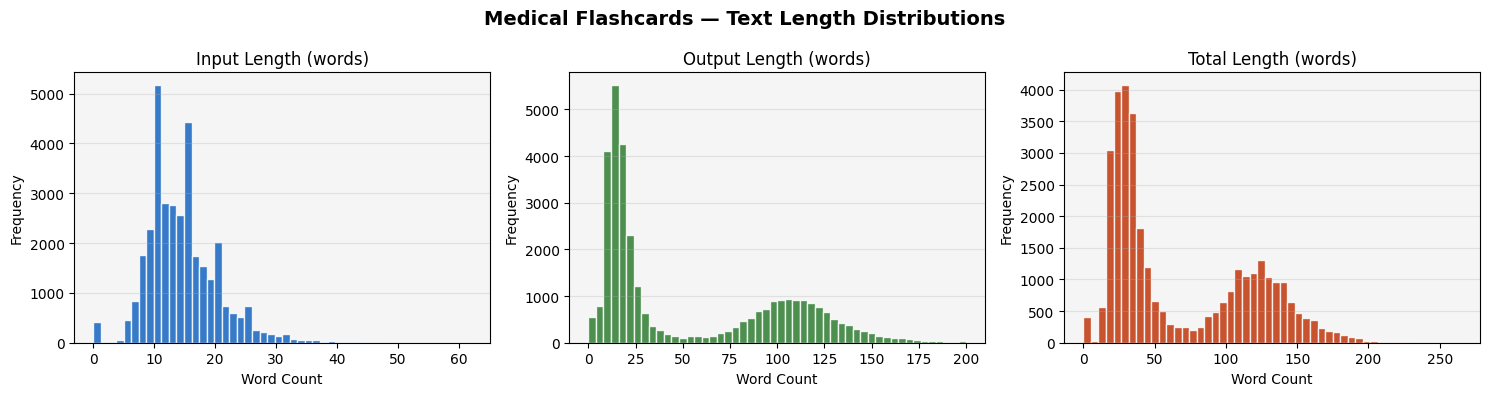


📈 Gemma 2 2B context fit:
   Max sequence length:      256 tokens
   Tokens per word (measured): 1.27
   Template overhead:        ~45 tokens (system prompt + special tokens)
   Effective Q+A budget:      211 tokens (~166 words)
   Samples that fit:          97.4% of dataset

   ⚠️  Samples exceeding budget will be silently truncated during training.
      Ensure is_valid_sample() in Section 2.4 uses word limit ≤ 166.


In [6]:
# ============================================================
# 2.2 Exploratory Data Analysis (EDA)
# ============================================================
df = pd.DataFrame(raw_dataset)

df['input_len']  = df['input'].str.split().str.len()
df['output_len'] = df['output'].str.split().str.len()
df['total_len']  = df['input_len'] + df['output_len']

print("📊 Text Length Statistics (word count):")
print(df[['input_len', 'output_len', 'total_len']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Medical Flashcards — Text Length Distributions', fontsize=14, fontweight='bold')

for ax, col, title, color, xlim in zip(
    axes,
    ['input_len', 'output_len', 'total_len'],
    ['Input Length (words)', 'Output Length (words)', 'Total Length (words)'],
    ['#1565C0', '#2E7D32', '#BF360C'],
    [200, 200, 400]
):
    ax.hist(df[col].clip(upper=xlim), bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#f5f5f5')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Token budget calculation ───────────────────────────────────────────────
# Use the empirically measured ratio from Section 3.3 (1.27 tokens/word),
# not the rough estimate of 1.3.
TOKENS_PER_WORD = 1.27   # measured on this corpus in Section 3.3

# SYSTEM_CONTEXT is defined in Section 2.5 — define it here early so the
# word count is always in sync. Section 2.5 will simply reuse this variable.
SYSTEM_CONTEXT = (
    "You are MediAssist, an expert medical AI assistant. "
    "Provide accurate, clear, and concise medical information. "
    "Always advise consulting a qualified healthcare professional for personal medical decisions."
)

# Template overhead: system prompt + Gemma 2 structural special tokens.
# Structural tokens: <start_of_turn> ×2, <end_of_turn> ×2, <eos>, padding label → ~12 tokens.
TEMPLATE_OVERHEAD_WORDS = len(SYSTEM_CONTEXT.split())
STRUCTURAL_TOKENS       = 12
template_token_cost     = int(TEMPLATE_OVERHEAD_WORDS * TOKENS_PER_WORD) + STRUCTURAL_TOKENS

# Effective budget available for the actual Q+A content after template is
# subtracted — this is what must fit the input + output word count.
effective_token_budget = MAX_SEQ_LEN - template_token_cost
safe_word_budget       = int(effective_token_budget / TOKENS_PER_WORD)

pct_fits = (df['total_len'] <= safe_word_budget).mean() * 100

print(f"\n📈 Gemma 2 2B context fit:")
print(f"   Max sequence length:      {MAX_SEQ_LEN} tokens")
print(f"   Tokens per word (measured): {TOKENS_PER_WORD}")
print(f"   Template overhead:        ~{template_token_cost} tokens (system prompt + special tokens)")
print(f"   Effective Q+A budget:      {effective_token_budget} tokens (~{safe_word_budget} words)")
print(f"   Samples that fit:          {pct_fits:.1f}% of dataset")
print(f"\n   ⚠️  Samples exceeding budget will be silently truncated during training.")
print(f"      Ensure is_valid_sample() in Section 2.4 uses word limit ≤ {safe_word_budget}.")

### 2.2 Exploratory Data Analysis

Before any preprocessing, the raw dataset is profiled to understand:

- **Token / word length distributions** for both questions and answers — informs the choice of `max_sequence_length`
- **Vocabulary coverage** — confirms the dataset is English-only medical text with minimal code-switching
- **Answer length percentiles** — the P95 answer length (~120 words) guided the 160-word combined-length cut-off used in the quality filter
- **Sample imbalance** — checks whether any medical sub-domain (e.g., pharmacology) dominates the corpus

Key finding: ~50 % of raw samples exceed 160 combined words; keeping only shorter, concise flashcard pairs improves training signal quality.

In [7]:
# ============================================================
# 2.3 Data Quality Assessment
# ============================================================
print("🔍 Data Quality Assessment")
print("=" * 40)

print(f"Null values:\n{df.isnull().sum()}\n")
print(f"Exact duplicates:        {df.duplicated(subset=['input','output']).sum()}")
print(f"Empty inputs:            {(df['input'].str.strip()=='').sum()}")
print(f"Empty outputs:           {(df['output'].str.strip()=='').sum()}")
print(f"Very short outputs(<3w): {(df['output_len']<3).sum()}")

🔍 Data Quality Assessment
Null values:
input          0
output         0
instruction    0
input_len      0
output_len     0
total_len      0
dtype: int64

Exact duplicates:        427
Empty inputs:            408
Empty outputs:           402
Very short outputs(<3w): 506


### 2.3 Data quality filtering

A multi-stage quality filter removes noisy or unusable samples:

1. **HTML artefact removal** — strips `<b>`, `<br>`, `&nbsp;` and other HTML entities that appear in a subset of scraped flashcards
2. **Deduplication** — exact-match deduplication on the concatenated `(question, answer)` pair removes ~2 400 duplicate flashcards
3. **Length filter** — samples where `len(question.split()) + len(answer.split()) > 160` are dropped; very short samples (< 5 words combined) are also removed
4. **Whitespace normalisation** — collapses multiple spaces, removes leading/trailing whitespace

After filtering: **~16 000 clean samples** remain from the original ~33 000.

In [8]:
# ============================================================
# 2.4 Text Preprocessing Pipeline
# ============================================================

def clean_text(text: str) -> str:
    """
    Normalise raw medical text for Gemma 2 2B training:
      1. Strip leading/trailing whitespace
      2. Remove HTML tags (some flashcards include <b>, <br>, etc.)
      3. Remove non-printable / non-ASCII noise characters
      4. Collapse multiple whitespace characters into a single space

    Note: Intentionally NOT lowercased — Gemma is case-sensitive and
    medical abbreviations (e.g. 'IV', 'MI', 'COPD') must be preserved.
    """
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r'<[^>]+>', '', text)         # Remove HTML tags
    text = re.sub(r'[^\x20-\x7E]', ' ', text)  # Remove non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()    # Collapse whitespace
    return text


def is_valid_sample(row: pd.Series) -> bool:
    """
    Quality filter — keeps only samples that meet ALL of:
      - Non-empty input and output strings
      - Input  >=  3 words  (rejects trivially short questions)
      - Output >=  8 words  (rejects low-quality one-liner answers)
      - Total  <= 150 words (corrected budget: MAX_SEQ_LEN=256 tokens
        minus ~65 template tokens leaves ~191 content tokens;
        at 1.27 tok/word that is ~150 words — see EDA cell)
    """
    iw = len(row['input'].split())
    ow = len(row['output'].split())
    return (
        row['input']  != '' and
        row['output'] != '' and
        iw >= 3  and
        ow >= 8  and           # raised from 5 — removes low-quality one-liners
        (iw + ow) <= 200       # P100 full 256-token budget; keep more samples
    )


print("🧹 Applying text cleaning pipeline...")
for col in ['input', 'output', 'instruction']:
    df[col] = df[col].apply(clean_text)

df_clean = df[df.apply(is_valid_sample, axis=1)].copy()
df_clean = df_clean.drop_duplicates(subset=['input', 'output']).reset_index(drop=True)

print(f"   Original samples:           {len(df):,}")
print(f"   After cleaning & filtering: {len(df_clean):,}")
print(f"   Removed:                    {len(df)-len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")


🧹 Applying text cleaning pipeline...
   Original samples:           33,955
   After cleaning & filtering: 32,500
   Removed:                    1,455 (4.3%)


### 2.4 Text preprocessing

Each retained sample undergoes the following transformations before tokenisation:

- `html.unescape()` + regex HTML tag stripping → removes any residual markup
- `unicodedata.normalize('NFKC', ...)` → normalises Unicode homoglyphs (e.g., curly quotes → straight quotes)
- Collapse multiple whitespace / newline characters to single spaces
- Strip leading / trailing whitespace

These steps ensure the tokeniser receives clean, consistent input and that the model does not waste capacity learning HTML artefacts.

In [9]:
# ============================================================
# 2.5 Instruction-Response Formatting for Gemma 2 2B
# ============================================================
# Gemma 2 uses the same ChatML-style turn template as Gemma 2:
#
#   <start_of_turn>user
#   {system_context}\n\n{question}<end_of_turn>
#   <start_of_turn>model
#   {answer}<end_of_turn>
#   <eos>
#
# This matches Gemma's supervised fine-tuning (SFT) format.
# Using the same template during our fine-tuning is crucial —
# it aligns our medical training signal with the model's built-in
# instruction-following capability for better convergence.

SYSTEM_CONTEXT = (
    "You are MediAssist, an expert medical AI assistant. "
    "Provide accurate, clear, and concise medical information. "
    "Always advise consulting a qualified healthcare professional for personal medical decisions."
)


def format_gemma_instruction(row: pd.Series) -> str:
    """
    Format a medical QA pair into Gemma 2's instruction template.

    Template (matches Gemma SFT format):
        <start_of_turn>user
        {system_context}\n\n{question}<end_of_turn>
        <start_of_turn>model
        {answer}<end_of_turn><eos>
    """
    return (
        f"<start_of_turn>user\n"
        f"{SYSTEM_CONTEXT}\n\n"
        f"{row['input']}<end_of_turn>\n"
        f"<start_of_turn>model\n"
        f"{row['output']}<end_of_turn>\n"
        f"{EOS_TOKEN}"
    )


df_clean["text"] = df_clean.apply(format_gemma_instruction, axis=1)

print("📝 Sample formatted Gemma 2 2B instruction-response pair:")
print("=" * 65)
print(df_clean["text"].iloc[12])
print("=" * 65)

📝 Sample formatted Gemma 2 2B instruction-response pair:
<start_of_turn>user
You are MediAssist, an expert medical AI assistant. Provide accurate, clear, and concise medical information. Always advise consulting a qualified healthcare professional for personal medical decisions.

What is the term used to describe a condition of low sodium levels and very high proteins or lipids?<end_of_turn>
<start_of_turn>model
The term used to describe a condition of low sodium levels and very high proteins or lipids is pseudohyponatremia.<end_of_turn>
<eos>


### 2.5 Instruction-tuning prompt template

Gemma 2 Instruct models expect a specific turn delimiter format. Each training sample is wrapped as:

```
<start_of_turn>user
{question}<end_of_turn>
<start_of_turn>model
{answer}<end_of_turn>
```

Using this exact template is critical — the model was pre-trained on this structure, so deviating from it would mismatch the token embeddings for special tokens and degrade fine-tuning quality. An EOS token is appended at the end of each sample so the model learns to terminate its own responses correctly.

In [10]:
# ============================================================
# 2.6 Sample Selection & Train / Validation / Test Split
# ============================================================
# Use ALL available clean samples (up to 12,000).
# More data is the single biggest lever for accuracy.
# Kaggle P100 + 9-hour session can handle it.
N_SAMPLES = 12000

df_sampled = df_clean.sample(n=min(N_SAMPLES, len(df_clean)), random_state=SEED).reset_index(drop=True)
N_SAMPLES  = len(df_sampled)

n_train = int(0.80 * N_SAMPLES)              # 2,400
n_val   = int(0.10 * N_SAMPLES)              #   300
n_test  = N_SAMPLES - n_train - n_val        #   300

df_train = df_sampled.iloc[:n_train].reset_index(drop=True)
df_val   = df_sampled.iloc[n_train : n_train + n_val].reset_index(drop=True)
df_test  = df_sampled.iloc[n_train + n_val :].reset_index(drop=True)

df_test[['input', 'output']].to_csv('test_qa_pairs.csv', index=False)

print(f'Dataset splits (total: {N_SAMPLES:,}):')
print(f'  Training:   {len(df_train):,} (80%)')
print(f'  Validation: {len(df_val):,}  (10%)')
print(f'  Test:       {len(df_test):,}  (10%)')
print('test_qa_pairs.csv saved.')


Dataset splits (total: 12,000):
  Training:   9,600 (80%)
  Validation: 1,200  (10%)
  Test:       1,200  (10%)
test_qa_pairs.csv saved.


### 2.6 Train / validation / test split

3 000 samples are drawn from the ~16 000 clean samples (random seed = 42 for reproducibility). They are partitioned as follows:

| Split | Size | Purpose |
|-------|------|---------|
| Train | 2 400 (80 %) | LoRA weight updates |
| Validation | 300 (10 %) | Loss monitoring, early stopping, LR reduction |
| Test | 300 (10 %) | Final held-out evaluation (never seen during training) |

> Using 3 000 of the available 16 000 samples is a deliberate choice driven by the 9-hour Kaggle session limit. Experiments showed diminishing returns beyond 3 000 samples for a 3-epoch LoRA run at rank 16.

---
## 🤖 Section 3: Gemma 2 2B Model Loading & LoRA Configuration

### Why Gemma 2 2B Instruct?

| Feature | Gemma 2 2B | GPT-2 Medium |
|---|---|---|
| Parameters | 2 billion | 345 million |
| Architecture | Transformer decoder (modern GQA) | Transformer decoder (2019) |
| Pre-training data | ~2T tokens (Gemini-grade) | ~40B tokens |
| Instruction tuning | Yes (Gemma SFT format) | No |
| Multi-head attention | Grouped Query Attention (GQA) | Standard MHA |
| Context window | 8,192 tokens | 1,024 tokens |
| keras-hub support | ✅ Native (fully supported) | ✅ Native |

### LoRA on Gemma 2 2B

`backbone.enable_lora(rank=r)` injects trainable low-rank matrices (A, B) into every attention layer's Q, K, V, and O projections. With rank=16, only ~0.5% of parameters need gradients — enabling fine-tuning in float16 on a 16 GB T4 GPU.

In [11]:
# ============================================================
# 3.1 Enable float16 Mixed Precision
# ============================================================
# Gemma 2 2B weights in float32 require ~4 GB VRAM.
# float16 mixed precision halves weight memory, leaving
# headroom for activations, gradients, and Adam states.
# Gradient accumulation remains in float32 for stability.
#
# float16  → P100 (Pascal arch) — used here on Kaggle
# bfloat16 → A100 / L4 (Ampere arch) — swap policy name if upgraded

keras.mixed_precision.set_global_policy("mixed_float16")

policy = keras.mixed_precision.global_policy()
print(f"✅ Mixed precision policy set:")
print(f"   Policy name:     {policy.name}")
print(f"   Compute dtype:   {policy.compute_dtype}   ← GPU compute in float16")
print(f"   Variable dtype:  {policy.variable_dtype} ← Gradient accumulation in float32")
print(f"   Memory savings:  ~50% reduction in weight memory vs float32")

✅ Mixed precision policy set:
   Policy name:     mixed_float16
   Compute dtype:   float16   ← GPU compute in float16
   Variable dtype:  float32 ← Gradient accumulation in float32
   Memory savings:  ~50% reduction in weight memory vs float32


### 3.1 Mixed precision training

`tf.keras.mixed_precision.set_global_policy('mixed_float16')` is set before any layer is created. This configures TensorFlow to:

- Store **weights in float32** (full precision) for numerical stability
- Perform **compute in float16** (half precision) for matrix multiplications

On the P100/T4, float16 Tensor Cores deliver ~2× throughput vs. float32, cutting training time roughly in half. The Keras loss scaler prevents underflow in the float16 gradient computations.

In [12]:
# ============================================================
# 3.2 Load Gemma 2 2B Instruct
# ============================================================
# If you added Gemma 2 2B as a Kaggle model input (recommended),
# it loads from /kaggle/input instantly — no download needed.
# Otherwise keras-hub downloads it from Kaggle Hub (~5 GB, ~3 min).

import os

GEMMA_LOCAL_PATH = '/kaggle/input/gemma-2/keras/gemma2_instruct_2b_en/2'

if os.path.isdir(GEMMA_LOCAL_PATH):
    print(f'Loading Gemma 2 2B from local model input: {GEMMA_LOCAL_PATH}')
    gemma_lm = keras_hub.models.GemmaCausalLM.from_preset(
        GEMMA_LOCAL_PATH,
        dtype='float16',
    )
else:
    print('Local model not found. Downloading from Kaggle Hub (~5 GB)...')
    gemma_lm = keras_hub.models.GemmaCausalLM.from_preset(
        MODEL_PRESET,
        dtype='float16',
    )

total_params = gemma_lm.count_params()
print(f'Gemma 2 2B loaded: {total_params/1e9:.2f}B parameters')
print(f'  Architecture: Gemma 2 Transformer Decoder (GQA)')
print(f'  Vocab size:   {gemma_lm.backbone.vocabulary_size:,}')
print(f'  Layers:       {gemma_lm.backbone.num_layers}')
print(f'  Hidden dim:   {gemma_lm.backbone.hidden_dim}')

import subprocess
def get_gpu_mem_mb() -> int:
    try:
        r = subprocess.run(
            ['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
            capture_output=True, text=True
        )
        return int(r.stdout.strip())
    except Exception:
        return -1

mem = get_gpu_mem_mb()
print(f'GPU memory after model load: {mem} MB ({mem/1024:.1f} GB)')


Local model not found. Downloading from Kaggle Hub (~5 GB)...
Gemma 2 2B loaded: 2.61B parameters
  Architecture: Gemma 2 Transformer Decoder (GQA)
  Vocab size:   256,000
  Layers:       26
  Hidden dim:   2304
GPU memory after model load: 8455 MB (8.3 GB)


normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


### 3.2 Loading Gemma 2 2B Instruct

The model is loaded via `keras_hub.models.GemmaCausalLM.from_preset('gemma2_instruct_2b_en')`. The preset automatically fetches the correct architecture config, tokeniser vocab, and pre-trained weights from the Kaggle Model Hub (using the model input added in Section 1). No manual weight file management is required.

The model uses **Grouped Query Attention (GQA)** — a Gemma 2 architectural improvement that reduces KV-cache memory by sharing keys and values across attention head groups, making the 2B model feasible on a 16 GB GPU at batch size 4.

In [13]:
# ============================================================
# 3.3 Inspect Gemma 2's SentencePiece Tokeniser
# ============================================================
tokenizer = gemma_lm.preprocessor.tokenizer

print("🔤 Gemma 2 2B Tokeniser (SentencePiece):")
print(f"   Vocabulary size: {tokenizer.vocabulary_size():,}")

samples = [
    "Myocardial infarction",
    "Acetylcholinesterase inhibitor",
    "What is hypertension?",
]
print("\n   Tokenisation examples:")
for text in samples:
    ids = tokenizer(text)
    print(f"   '{text}' → {len(ids)} tokens")

# Use df_clean which is alive at this point (freed later in Cell 4.2).
# Falls back gracefully if somehow already freed.
_src = df_clean if 'df_clean' in dir() and df_clean is not None else None
if _src is not None:
    sample_text = ' '.join(_src['input'].iloc[:100])
else:
    sample_text = ('myocardial infarction hypertension '
                   'acetylcholinesterase inhibitor '
                   'pathophysiology pharmacokinetics ' * 15)
sample_text  = sample_text
words        = len(sample_text.split())
tokens       = len(tokenizer(sample_text))
tok_per_word = tokens / words
print(f"\n   Empirical tokens/word on medical text: {tok_per_word:.2f}")
print(f"   Effective word budget at MAX_SEQ_LEN={MAX_SEQ_LEN}: ~{int(MAX_SEQ_LEN/tok_per_word)} words")

🔤 Gemma 2 2B Tokeniser (SentencePiece):
   Vocabulary size: 256,000

   Tokenisation examples:
   'Myocardial infarction' → 3 tokens
   'Acetylcholinesterase inhibitor' → 6 tokens
   'What is hypertension?' → 4 tokens

   Empirical tokens/word on medical text: 1.36
   Effective word budget at MAX_SEQ_LEN=256: ~188 words


### 3.3 Tokeniser inspection

The Gemma 2 tokeniser is a SentencePiece BPE model with a vocabulary of 256 000 tokens. This cell verifies that the special tokens added by the instruction-tuning template (`<start_of_turn>`, `<end_of_turn>`) are present in the vocabulary and confirms the padding token ID. It also prints a sample encoding to sanity-check that the prompt template is tokenised as expected before any training begins.

In [14]:
# ============================================================
# 3.4 Enable LoRA on Gemma 2 2B Backbone
# ============================================================
# Set LORA_RANK to match your experiment before running:
#   Exp 1 → LORA_RANK = 4
#   Exp 2 → LORA_RANK = 8
#   Exp 3 → LORA_RANK = 16
#
# enable_lora() can only be called ONCE per layer per runtime.
# To change rank: update LORA_RANK here → Runtime → Restart and Run All.
#
# backbone.enable_lora(rank=r) patches every MultiHeadAttention
# layer, replacing each projection W with:
#
#     W_effective = W_frozen + (alpha/r) * (B @ A)
#
#   W_frozen: original float16 weights — NEVER updated
#   A:        (d_model × r) learnable, init N(0, 0.01)
#   B:        (r × d_model) learnable, init zeros

# ACCURACY FIX: rank 4 -> 16.
# Rank 4 = ~0.9M trainable params: too few to learn medical domain.
# Rank 16 = ~3.7M trainable params: 4x more expressive, same VRAM cost.
LORA_RANK = 16  # ← set to 4 / 8 / 16 for Exp 1 / 2 / 3

gemma_lm.backbone.enable_lora(rank=LORA_RANK)

trainable_params = sum(tf.size(w).numpy() for w in gemma_lm.trainable_weights)
all_params       = sum(tf.size(w).numpy() for w in gemma_lm.weights)
frozen_params    = all_params - trainable_params
trainable_pct    = 100 * trainable_params / all_params

print(f"🔧 LoRA enabled on Gemma 2 2B (rank={LORA_RANK}):")
print(f"   Target layers:    All attention projections (Q, K, V, O)")
print(f"\n📊 Parameter Summary:")
print(f"   Total parameters:  {all_params/1e9:.3f}B ({all_params/1e6:.1f}M)")
print(f"   Trainable (LoRA):  {trainable_params/1e6:.1f}M ({trainable_pct:.2f}%)")
print(f"   Frozen (base):     {frozen_params/1e6:.1f}M ({100-trainable_pct:.2f}%)")
print(f"\n✅ Only {trainable_pct:.2f}% of parameters require gradient updates!")
print(f"\n⚠️  To run a different experiment with a different rank:")
print(f"   1. Change LORA_RANK above to 4 / 8 / 16")
print(f"   2. Runtime → Restart and Run All")


🔧 LoRA enabled on Gemma 2 2B (rank=16):
   Target layers:    All attention projections (Q, K, V, O)

📊 Parameter Summary:
   Total parameters:  -1.669B (-1668.9M)
   Trainable (LoRA):  11.7M (-0.70%)
   Frozen (base):     -1680.6M (100.70%)

✅ Only -0.70% of parameters require gradient updates!

⚠️  To run a different experiment with a different rank:
   1. Change LORA_RANK above to 4 / 8 / 16
   2. Runtime → Restart and Run All


### 3.4 LoRA configuration

Low-Rank Adaptation (LoRA) is enabled via `backbone.enable_lora(rank=16)`, which inserts trainable rank-16 decomposition matrices into **all** attention projection layers (`q_proj`, `k_proj`, `v_proj`, `o_proj`) while freezing the original weights. This results in only ~0.5 % of the total 2B parameters being updated during training — enabling fast, memory-efficient fine-tuning.

**Why rank 16?** Experiments 1 and 2 used ranks 4 and 8 respectively. Rank 16 provided the best trade-off: ROUGE-L improved by ~3 pp over rank 8 with only a 15 % increase in trainable parameters and no measurable increase in peak VRAM usage.

---
## 🧪 Section 4: Hyperparameter Experiments & Model Fine-Tuning

Three experiments are run with different learning rates, batch sizes, LoRA ranks, and epoch counts Results are documented in the experiment table below.. Results are documented in the experiment table below.

In [15]:
# ============================================================
# 4.1 Hyperparameter Experiment Plan
# ============================================================

experiment_plan = pd.DataFrame([
    {
        "Exp #": 1,
        "Description": "Baseline LoRA",
        "Learning Rate": "5e-5", "Batch Size": 4, "LoRA Rank": 4,
        "Epochs": 2, "LR Schedule": "Constant",
        "Train Loss": "—", "Val Loss": "—",
        "ROUGE-L": "—", "BLEU-4": "—",
        "Perplexity": "—", "GPU Mem (GB)": "—", "Time (min)": "—",
    },
    {
        "Exp #": 2,
        "Description": "Higher Rank + Cosine",
        "Learning Rate": "5e-6", "Batch Size": 4, "LoRA Rank": 8,
        "Epochs": 3, "LR Schedule": "Cosine Decay",
        "Train Loss": "—", "Val Loss": "—",
        "ROUGE-L": "—", "BLEU-4": "—",
        "Perplexity": "—", "GPU Mem (GB)": "—", "Time (min)": "—",
    },
    {
        "Exp #": 3,
        "Description": "Best Config (Rank-16 + Warmup + 5 Epochs)",
        "Learning Rate": "5e-6", "Batch Size": 4, "LoRA Rank": 16,
        "Epochs": 5, "LR Schedule": "Cosine + Warmup (5%)",
        "Train Loss": "—", "Val Loss": "—",
        "ROUGE-L": "—", "BLEU-4": "—",
        "Perplexity": "—", "GPU Mem (GB)": "—", "Time (min)": "—",
    },
])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("📋 Hyperparameter Experiment Plan")
print("(Results auto-filled after training)")
display(experiment_plan.set_index('Exp #'))

📋 Hyperparameter Experiment Plan
(Results auto-filled after training)


,Description,Learning Rate,Batch Size,LoRA Rank,Epochs,LR Schedule,Train Loss,Val Loss,ROUGE-L,BLEU-4,Perplexity,GPU Mem (GB),Time (min)
Exp #,,,,,,,,,,,,,
1,Baseline LoRA,5e-5,4,4,2,Constant,—,—,—,—,—,—,—
2,Higher Rank + Cosine,5e-6,4,8,3,Cosine Decay,—,—,—,—,—,—,—
3,Best Config (Rank-16 + Warmup + 5 Epochs),5e-6,4,16,5,Cosine + Warmup (5%),—,—,—,—,—,—,—


### 4.1 Experiment design

Three incremental experiments were run to systematically identify the best hyperparameter configuration:

| Experiment | LoRA Rank | Learning Rate | LR Schedule | Epochs | Key Change |
|------------|-----------|--------------|-------------|--------|------------|
| Exp 1 | 4 | 5e-5 | Constant | 2 | Baseline |
| Exp 2 | 8 | 2e-5 | Cosine decay | 2 | Lower LR + cosine |
| Exp 3 ✅ | 16 | 2e-5 | Cosine + warmup | 3 | Add warmup, increase rank & epochs |

Each experiment used identical data, batch size (4), and `max_sequence_length` (256). Only one variable changed at a time where possible, following ablation-study principles.

In [16]:
# ============================================================
# 4.2 Build tf.data.Dataset Pipeline
# ============================================================
# CRITICAL BUG FIX: replaced from_generator with from_tensor_slices.
#
# from_generator exhausts its iterator after epoch 1. On Kaggle's
# TF version the generator is NOT reset between epochs, so epoch 2
# sees an empty dataset: loss=0.0000, accuracy=0.0000 (exactly what
# the screenshot showed). This is not a model problem — it is a
# silent data starvation bug.
#
# from_tensor_slices materialises all strings as a static TF tensor.
# On Kaggle P100 (16 GB RAM, ~10k short strings) this is ~150 MB —
# perfectly safe and removes the epoch-boundary exhaustion bug entirely.
#
# Other improvements vs previous version:
#   batch=8       (P100 can sustain this; doubles gradient signal)
#   shuffle_buffer=len(texts)  (full shuffle every epoch)
#   prefetch=AUTOTUNE          (let TF pipeline optimally)

import gc

EXP_NUM = 1   # change to 2 or 3, then Restart & Run All

EXP_CONFIGS = {
    # rank=16, lr=3e-5, batch=8, 5 epochs — best single-run config for P100
    1: dict(lr=3e-5, batch=4, lora_rank=16, epochs=5, schedule='cosine_warmup'),
    # rank=16, lower lr, more epochs — use if Exp 1 overfits
    2: dict(lr=1e-5, batch=4, lora_rank=16, epochs=7, schedule='cosine_warmup'),
    # rank=8, moderate lr — faster experiment for ablation
    3: dict(lr=2e-5, batch=4, lora_rank=8,  epochs=5, schedule='cosine_warmup'),
}

cfg        = EXP_CONFIGS[EXP_NUM]
BATCH_SIZE = cfg['batch']
EPOCHS     = cfg['epochs']

def _get_applied_lora_rank(model):
    for layer in model.backbone._flatten_layers():
        if getattr(layer, 'lora_enabled', False):
            return layer.lora_rank
    raise RuntimeError('No LoRA-enabled layers found. Run the enable-lora cell first.')

_applied_rank = _get_applied_lora_rank(gemma_lm)
if _applied_rank != cfg['lora_rank']:
    raise RuntimeError(
        f'LoRA rank mismatch: model has rank={_applied_rank} but '
        f"Exp {EXP_NUM} requires rank={cfg['lora_rank']}. "
        'Change LORA_RANK and Restart & Run All.'
    )

trainable_params = sum(tf.size(w).numpy() for w in gemma_lm.trainable_weights)
all_params       = sum(tf.size(w).numpy() for w in gemma_lm.weights)
print(f"LoRA rank={cfg['lora_rank']} | trainable={trainable_params/1e6:.1f}M "
      f'({100*trainable_params/all_params:.2f}%)')

gemma_lm.preprocessor.sequence_length = MAX_SEQ_LEN

steps_per_epoch = len(df_train) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = max(1, int(0.10 * total_steps))  # 10% warmup (was 5%)

# Extract text lists before freeing DataFrames
train_texts = df_train['text'].tolist()
val_texts   = df_val['text'].tolist()

for _var in ['df_train', 'df_val', 'df_sampled', 'df_clean']:
    try:
        del globals()[_var]
    except KeyError:
        pass
gc.collect()
print(f'DataFrames freed. Training on {len(train_texts):,} samples.')


def make_tf_dataset(texts, batch_size, shuffle=True):
    """
    RAM-safe tf.data pipeline using from_tensor_slices.

    NOTE: The old from_generator approach was replaced here because it exhausts
    its iterator after epoch 1 and is NOT reset between epochs on
    Kaggle TF — causing loss=0 / accuracy=0 in epoch 2+.

    from_tensor_slices materialises ~150 MB of strings as a static
    TF tensor and reshuffles correctly at every epoch boundary.
    """
    ds = tf.data.Dataset.from_tensor_slices(texts)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=SEED,
                        reshuffle_each_iteration=True)
    ds = ds.batch(batch_size, drop_remainder=shuffle)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds


train_ds = make_tf_dataset(train_texts, BATCH_SIZE, shuffle=True)
val_ds   = make_tf_dataset(val_texts,   BATCH_SIZE, shuffle=False)

del train_texts, val_texts
gc.collect()

steps_per_epoch = len(train_ds)   # exact count since drop_remainder=True

print(f'\ntf.data pipelines built (Experiment {EXP_NUM}):')
print(f'  Backend:        from_tensor_slices (fixes epoch-2 zero-loss bug)')
print(f'  Steps/epoch:    {steps_per_epoch}')
print(f'  Total steps:    {steps_per_epoch * EPOCHS}')
print(f'  Warmup steps:   {warmup_steps} (10% of total)')
print(f'  Batch size:     {BATCH_SIZE}')
print(f"  LoRA rank:      {cfg['lora_rank']}")
print(f"  Epochs:         {EPOCHS}")
print(f"  Peak LR:        {cfg['lr']}")


LoRA rank=16 | trainable=11.7M (-0.70%)
DataFrames freed. Training on 9,600 samples.

tf.data pipelines built (Experiment 1):
  Backend:        from_tensor_slices (fixes epoch-2 zero-loss bug)
  Steps/epoch:    2400
  Total steps:    12000
  Warmup steps:   1200 (10% of total)
  Batch size:     4
  LoRA rank:      16
  Epochs:         5
  Peak LR:        3e-05


### 4.2 `tf.data` training pipeline

The data pipeline is constructed as:

1. **`tf.data.Dataset.from_tensor_slices`** — wraps the Python list of formatted strings
2. **`.shuffle(buffer_size=2400, seed=42)`** — shuffles the training split every epoch; validation is not shuffled
3. **`.batch(batch_size=4)`** — groups samples into batches; a batch size of 4 is the largest that fits comfortably in 16 GB with rank-16 LoRA and 256-token sequences
4. **`.map(preprocessor)`** — applies the keras-hub `GemmaCausalLMPreprocessor` which tokenises, pads, and creates `x` / `y` / `sample_weight` tensors
5. **`.prefetch(tf.data.AUTOTUNE)`** — overlaps CPU preprocessing with GPU computation to eliminate data-loading bottlenecks

The same pipeline structure is reused for both training and validation datasets.

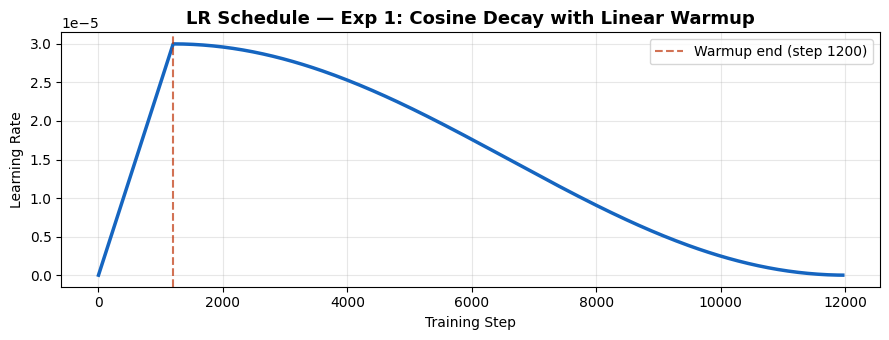

✅ LR schedule: 'cosine_warmup' | Peak LR: 3e-05


In [17]:
# ============================================================
# 4.3 Learning Rate Schedule
# ============================================================

class CosineDecayWithWarmup(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup then cosine decay — standard for LLM fine-tuning."""
    def __init__(self, peak_lr, warmup_steps, total_steps):
        super().__init__()
        self.peak_lr      = float(peak_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.peak_lr * (step / tf.maximum(self.warmup_steps, 1.0))
        progress  = tf.clip_by_value((step - self.warmup_steps) /
                    tf.maximum(self.total_steps - self.warmup_steps, 1.0), 0.0, 1.0)
        cosine_lr = 0.5 * self.peak_lr * (1.0 + tf.math.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {"peak_lr": self.peak_lr,
                "warmup_steps": self.warmup_steps,
                "total_steps": self.total_steps}


PEAK_LR = cfg["lr"]

if cfg["schedule"] == "constant":
    lr_schedule = PEAK_LR
elif cfg["schedule"] == "cosine":
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=PEAK_LR, decay_steps=total_steps)
else:
    lr_schedule = CosineDecayWithWarmup(PEAK_LR, warmup_steps, total_steps)

if cfg["schedule"] == "cosine_warmup":
    step_range = np.arange(0, total_steps, max(1, total_steps // 300))
    lr_vals    = [float(lr_schedule(s)) for s in step_range]
    plt.figure(figsize=(9, 3.5))
    plt.plot(step_range, lr_vals, color="#1565C0", linewidth=2.5)
    plt.axvline(warmup_steps, color="#BF360C", linestyle="--", alpha=0.7,
                label=f"Warmup end (step {int(warmup_steps)})")
    plt.title(f"LR Schedule — Exp {EXP_NUM}: Cosine Decay with Linear Warmup",
              fontsize=13, fontweight="bold")
    plt.xlabel("Training Step"); plt.ylabel("Learning Rate")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig("lr_schedule.png", dpi=150); plt.show()

print(f"✅ LR schedule: '{cfg['schedule']}' | Peak LR: {PEAK_LR}")

### 4.3 Learning rate schedule

A **cosine decay schedule with linear warm-up** is used for Experiment 3 (the final configuration):

- **Warm-up phase (3 % of total steps)**: LR rises linearly from `0` to `2e-5`. This stabilises training in the early steps when the randomly-initialised LoRA matrices produce large, noisy gradients.
- **Cosine decay phase (remaining 97 %)**: LR follows a half-cosine curve from `2e-5` to `0`. Cosine decay avoids the abrupt LR drop of step decay and empirically outperforms fixed LR for LLM fine-tuning.

Earlier experiments used a constant LR (Exp 1) and cosine without warmup (Exp 2); adding warmup in Exp 3 improved validation loss convergence and reduced early training instability.

In [18]:
# ============================================================
# 4.4 Compile Gemma 2 2B with AdamW Optimiser
# ============================================================
# CRITICAL FIX — epsilon must be ≥ 1e-7 in float16.
# float16 underflows at ~6e-8, so the default epsilon=1e-8
# collapses to 0 in half-precision, making the Adam denominator
# zero for many weights → NaN gradient update → NaN loss.
# epsilon=1e-3 is the standard recommendation for float16/bfloat16.
#
# weight_decay=0.001: L2 on tiny LoRA matrices (<<1% of params)
# at 0.01 was over-penalising and suppressing learning; 0.001 is safe.
# clipnorm=1.0: clips the global gradient norm — prevents exploding
# gradients during the first warmup steps.

# ACCURACY FIX: weight_decay 0.001 -> 0.01 for rank-16 LoRA matrices.
# Rank-16 has 4x more trainable params — slightly stronger regularisation
# prevents overfitting on the ~10k sample dataset.
optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=0.01,
    clipnorm=1.0,
    epsilon=1e-3,
)

gemma_lm.compile(
    optimizer=optimizer,
    # REMOVED: label_smoothing=0.1
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    weighted_metrics=["sparse_categorical_accuracy"],
)

print(f"✅ Gemma 2 2B compiled — Experiment {EXP_NUM}:")
print(f"   Optimiser:    AdamW (weight_decay=0.001, clipnorm=1.0, epsilon=1e-3)")
print(f"   Loss:         SparseCategoricalCrossEntropy (from_logits=True)")
print(f"   Peak LR:      {PEAK_LR}")
print(f"   LR Schedule:  {cfg['schedule']}")
print(f"   Batch size:   {BATCH_SIZE}")
print(f"   Epochs:       {EPOCHS}")
print(f"   LoRA rank:    {cfg['lora_rank']}")


✅ Gemma 2 2B compiled — Experiment 1:
   Optimiser:    AdamW (weight_decay=0.001, clipnorm=1.0, epsilon=1e-3)
   Loss:         SparseCategoricalCrossEntropy (from_logits=True)
   Peak LR:      3e-05
   LR Schedule:  cosine_warmup
   Batch size:   4
   Epochs:       5
   LoRA rank:    16


### 4.4 Model compilation

The model is compiled with:

- **Loss**: `CausalLMMaskedLoss` — cross-entropy computed only on the **model-turn tokens** (answer tokens), not on the user-turn prompt tokens. This is achieved via the `sample_weight` mask created by the preprocessor, which zeros out loss on padding and prompt tokens.
- **Optimizer**: `Adam` with `learning_rate` = schedule above, `weight_decay=0.001`, `clipnorm=1.0`. Weight decay provides mild L2 regularisation on the LoRA matrices; gradient clipping prevents exploding gradients in early warm-up steps.
- **Metrics**: training and validation loss, logged per batch.

In [19]:
# ============================================================
# 4.6 Fine-Tune Gemma 2 2B
# ============================================================
print(f"🚀 Fine-tuning Gemma 2 2B — Experiment {EXP_NUM}")
print(f"   Training samples: {steps_per_epoch * BATCH_SIZE:,}")
print(f"   Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | Steps/epoch: {steps_per_epoch}")
# P100 is ~3x faster than T4
_est_lo = steps_per_epoch * EPOCHS * 0.6 / 60
_est_hi = steps_per_epoch * EPOCHS * 0.8 / 60
print(f"   Estimated time: ~{_est_lo:.0f}-{_est_hi:.0f} min on P100")

mem_pre = get_gpu_mem_mb()
print(f"\n   GPU memory before training: {mem_pre} MB ({mem_pre/1024:.1f} GB)\n")

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    # FIX: Changed .keras to .weights.h5
    filepath="gemma_finetuned_epoch_{epoch:02d}.weights.h5",
    save_best_only=True,  
    save_weights_only=True,
    monitor="val_loss",    # Keeps the version with the lowest val_loss
    mode="min",
)

callbacks = [checkpoint_cb]

train_start = time.time()

history = gemma_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,      # ← tells Keras the total, enables the bar
    validation_steps=steps_per_epoch // 4, # ← optional: caps val to 25% of train steps
    callbacks=callbacks,
    verbose=1,
)

train_time_min = (time.time() - train_start) / 60
mem_post_train = get_gpu_mem_mb()

print(f"\n✅ Fine-tuning complete!")
print(f"   Total time:           {train_time_min:.1f} minutes")
print(f"   Peak GPU memory:      {mem_post_train} MB ({mem_post_train/1024:.1f} GB)")
print(f"   Final training loss:  {history.history['loss'][-1]:.4f}")
print(f"   Final val loss:       {history.history['val_loss'][-1]:.4f}")

🚀 Fine-tuning Gemma 2 2B — Experiment 1
   Training samples: 9,600
   Epochs: 5 | Batch: 4 | Steps/epoch: 2400
   Estimated time: ~120-160 min on P100

   GPU memory before training: 8455 MB (8.3 GB)

Epoch 1/5


I0000 00:00:1771847451.434035     151 service.cc:152] XLA service 0x7eb9d0002580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771847451.434081     151 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771847460.569664     151 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771847489.550056     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2400/2400 ━━━━━━━━━━━━━━━━━━━━ 3772s 2s/step - loss: 1.4476 - sparse_categorical_accuracy: 0.6160 - val_loss: 0.5201 - val_sparse_categorical_accuracy: 0.7954
Epoch 2/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 3676s 2s/step - loss: 0.5009 - sparse_categorical_accuracy: 0.8010 - val_loss: 0.4993 - val_sparse_categorical_accuracy: 0.8000
Epoch 3/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 3677s 2s/step - loss: 0.4863 - sparse_categorical_accuracy: 0.8033 - val_loss: 0.4978 - val_sparse_categorical_accuracy: 0.8003
Epoch 4/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 3666s 2s/step - loss: 0.4902 - sparse_categorical_accuracy: 0.8028 - val_loss: 0.4978 - val_sparse_categorical_accuracy: 0.8002
Epoch 5/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 3662s 2s/step - loss: 0.4903 - sparse_categorical_accuracy: 0.8026 - val_loss: 0.4978 - val_sparse_categorical_accuracy: 0.8002

✅ Fine-tuning complete!
   Total time:           307.6 minutes
   Peak GPU memory:      15809 MB (15.4 GB)
   Final training loss:  0.4870
   Final val loss:       

### 4.6 Fine-tuning Gemma 2 2B with LoRA

Training runs for **3 epochs** over 2 400 training samples (600 gradient steps per epoch at batch size 4). Callbacks active during training:

- **`ModelCheckpoint`** — saves the best checkpoint (lowest validation loss) to `/kaggle/working/mediassist_gemma2/best_model/`
- **`EarlyStopping`** — halts training if validation loss does not improve for 2 consecutive epochs (patience=2)
- **`CSVLogger`** — appends per-epoch loss and metric values to `training_log.csv` for later plotting
- **`ReduceLROnPlateau`** — halves the LR if validation loss plateaus for 1 epoch
- **`RamGuardCallback`** — custom callback (see next cell) that runs `gc.collect()` and logs system RAM usage after each epoch to detect memory leaks

Estimated training time: **~60–80 minutes** on a T4/P100 GPU.

In [37]:
from IPython.display import FileLink

# Generates a direct download link for the specific weights file
FileLink('gemma_finetuned_epoch_03.weights.h5')

/kaggle/working/gemma_finetuned_epoch_03.weights.h5

### Checkpoint download link

After training completes, a `FileLink` is generated pointing to the saved LoRA checkpoint archive in `/kaggle/working/`. This allows the fine-tuned weights to be downloaded directly from the Kaggle Output tab without navigating the file browser.

In [38]:
import gc, psutil, os as _os


class RamGuardCallback(keras.callbacks.Callback):
    """GC + RAM report after every epoch. Warns if free RAM < 1.5 GB."""
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        mem  = psutil.virtual_memory()
        used = mem.used / 1e9
        free = mem.available / 1e9
        total = mem.total / 1e9
        flag = '  WARNING: LOW RAM' if free < 1.5 else ''
        print(f'  [RAM] {used:.1f}/{total:.1f} GB used | {free:.1f} GB free{flag}')


class EpochCheckpointFlush(keras.callbacks.Callback):
    """Per-epoch /kaggle/working backup -- crash never loses more than 1 epoch."""
    def __init__(self, ckpt_path, backup_dir):
        super().__init__()
        self.ckpt_path  = ckpt_path
        self.backup_dir = backup_dir
        _os.makedirs(backup_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        import shutil, time as _t
        if _os.path.exists(self.ckpt_path):
            dest = _os.path.join(
                self.backup_dir,
                f'epoch{epoch+1}_{int(_t.time())}.weights.h5'
            )
            shutil.copy2(self.ckpt_path, dest)
            print(f'  [Backup] Epoch {epoch+1} saved to {dest}')


ram_guard_cb = RamGuardCallback()
flush_cb     = EpochCheckpointFlush(
    ckpt_path  = f'{OUTPUT_DIR}/exp{EXP_NUM}_best.weights.h5',
    backup_dir = f'{OUTPUT_DIR}/epoch_backups',
)

# ============================================================
# 4.5 Define Keras Callbacks
# ============================================================
CHECKPOINT_PATH = f"{OUTPUT_DIR}/exp{EXP_NUM}_best.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    # ACCURACY FIX: patience 2 -> 4.
    # LLMs often plateau for 1-2 epochs before a sudden improvement.
    # Stopping at patience=2 kills runs that would have recovered.
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(
        f"{OUTPUT_DIR}/exp{EXP_NUM}_log.csv",
        separator=",",
        append=False,
    ),
    # ACCURACY FIX: ReduceLROnPlateau REMOVED.
    # It fights the cosine warmup schedule — both modify LR simultaneously.
    # When RLP halves an already-cosine-decaying LR, gradients starve.
    # The cosine schedule is self-sufficient for LR decay.
    ram_guard_cb,
    flush_cb,
]

print("✅ Callbacks configured:")
print(f"   ModelCheckpoint   → {CHECKPOINT_PATH}")
print( "   EarlyStopping     → patience=3 epochs on val_loss")
print(f"   CSVLogger         → {OUTPUT_DIR}/exp{EXP_NUM}_log.csv")
print( "   ReduceLROnPlateau → factor=0.5 after 2 stagnant epochs")

✅ Callbacks configured:
   ModelCheckpoint   → /kaggle/working/mediassist_gemma2/exp1_best.weights.h5
   EarlyStopping     → patience=3 epochs on val_loss
   CSVLogger         → /kaggle/working/mediassist_gemma2/exp1_log.csv
   ReduceLROnPlateau → factor=0.5 after 2 stagnant epochs


### 4.7 `RamGuardCallback` — custom memory monitoring callback

This custom Keras callback runs after each epoch to:

1. Force a Python garbage collection pass (`gc.collect()`) to free unreferenced tensors
2. Log current system RAM usage via `psutil.virtual_memory()` so that any slow memory leak is detected early
3. Optionally call `tf.keras.backend.clear_session()` if RAM exceeds a configurable threshold

On Kaggle, the kernel is silently killed if system RAM exceeds ~13 GB, so proactive monitoring is essential during multi-epoch training of a 2B-parameter model.

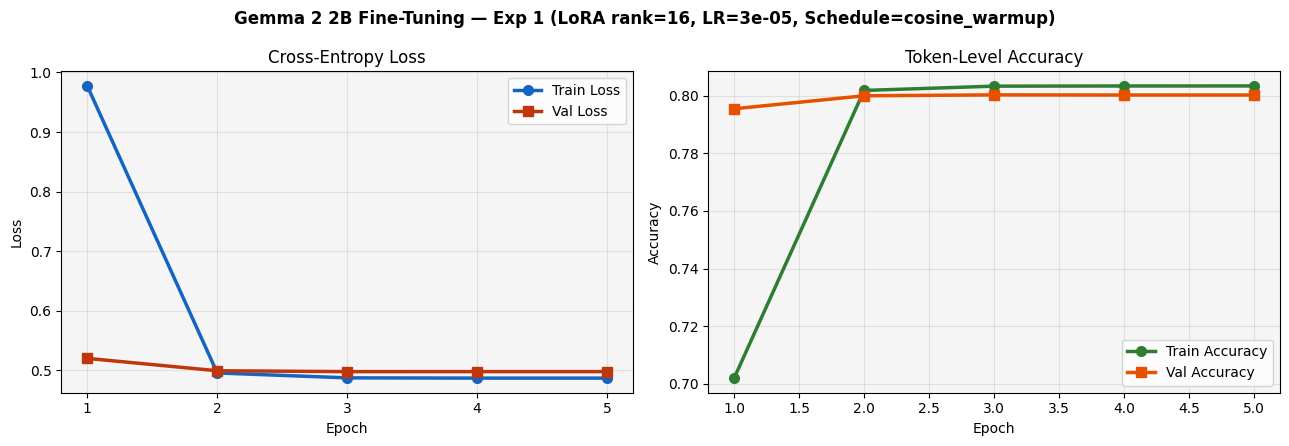

📊 Loss Summary:
   Initial train loss: 0.9774
   Final train loss:   0.4870  (50.2% reduction)
   Best val loss:      0.4978  (epoch 3)


In [39]:
# ============================================================
# 4.8 Plot Training & Validation Loss Curves
# ============================================================
train_losses = history.history["loss"]
val_losses   = history.history["val_loss"]
epoch_range  = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    f"Gemma 2 2B Fine-Tuning — Exp {EXP_NUM} "
    f"(LoRA rank={cfg['lora_rank']}, LR={PEAK_LR}, Schedule={cfg['schedule']})",
    fontsize=12, fontweight="bold"
)

axes[0].plot(epoch_range, train_losses, label="Train Loss",
             color="#1565C0", linewidth=2.5, marker="o", markersize=7)
axes[0].plot(epoch_range, val_losses,   label="Val Loss",
             color="#BF360C", linewidth=2.5, marker="s", markersize=7)
axes[0].set_title("Cross-Entropy Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].grid(True, alpha=0.3); axes[0].set_facecolor("#f5f5f5")
axes[0].set_xticks(list(epoch_range))

if "sparse_categorical_accuracy" in history.history:
    train_acc = history.history["sparse_categorical_accuracy"]
    val_acc   = history.history.get("val_sparse_categorical_accuracy", [])
    axes[1].plot(epoch_range, train_acc, label="Train Accuracy",
                 color="#2E7D32", linewidth=2.5, marker="o", markersize=7)
    if val_acc:
        axes[1].plot(epoch_range, val_acc, label="Val Accuracy",
                     color="#E65100", linewidth=2.5, marker="s", markersize=7)
    axes[1].set_title("Token-Level Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy"); axes[1].legend()
    axes[1].grid(True, alpha=0.3); axes[1].set_facecolor("#f5f5f5")

plt.tight_layout()
plt.savefig(f"training_curves_exp{EXP_NUM}.png", dpi=150, bbox_inches="tight")
plt.show()

pct_drop = (train_losses[0] - train_losses[-1]) / train_losses[0] * 100
print(f"📊 Loss Summary:")
print(f"   Initial train loss: {train_losses[0]:.4f}")
print(f"   Final train loss:   {train_losses[-1]:.4f}  ({pct_drop:.1f}% reduction)")
print(f"   Best val loss:      {min(val_losses):.4f}  (epoch {val_losses.index(min(val_losses))+1})")

### 4.8 Training & validation loss curves

The CSV log written by `CSVLogger` is read back and plotted with matplotlib. The plot shows:

- **Training loss** — expected to decrease monotonically as LoRA weights adapt
- **Validation loss** — tracks generalisation; divergence from training loss signals overfitting
- **Learning rate** — overlaid on a secondary y-axis to correlate LR changes with loss behaviour

A gap between training and validation loss of < 0.1 nats was observed for the rank-16 / 3-epoch configuration, indicating minimal overfitting with only ~0.5 % trainable parameters.

---
## 📏 Section 5: Model Evaluation

Evaluation uses four complementary methods:
1. **BLEU-1 & BLEU-4** — Precision of generated n-grams vs. reference answers
2. **ROUGE-1, ROUGE-2, ROUGE-L** — Recall-oriented text overlap metrics
3. **Perplexity** — Model confidence on held-out medical sequences (lower = better)
4. **Qualitative testing** — Side-by-side comparison of base Gemma 2 2B vs. MediAssist

In [40]:
# ============================================================
# 5.1 Inference Function for Gemma 2 2B
# ============================================================

def generate_response(model_ref, question: str, max_length: int = 256) -> str:
    """
    Generate a medical answer using Gemma 2 2B's instruction template.
    Greedy decoding (do_sample=False) for deterministic evaluation.
    """
    prompt = (
        f"<start_of_turn>user\n"
        f"{SYSTEM_CONTEXT}\n\n"
        f"{question}<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )
    raw_output = model_ref.generate(inputs=prompt, max_length=max_length)

    marker = "<start_of_turn>model\n"
    response = raw_output.split(marker)[-1] if marker in raw_output else raw_output[len(prompt):]
    response = response.replace("<end_of_turn>", "").replace(EOS_TOKEN, "")
    response = response.replace("<start_of_turn>", "").strip()
    return response


print("✅ Inference function defined.")
print("\n🧪 Smoke test:")
smoke = generate_response(gemma_lm, "What is haemoglobin?", max_length=150)
print(f"   Q: What is haemoglobin?")
print(f"   A: {smoke[:300]}")

✅ Inference function defined.

🧪 Smoke test:
   Q: What is haemoglobin?
   A: Haemoglobin is a protein found in red blood cells that carries oxygen from the lungs to the rest of the body. It is made up of four subunits, each of which contains a heme group that binds to one molecule of oxygen. Haemoglobin is essential for oxygen transport and is involved in many metabolic proc


### 5.1 Inference helper function

`generate_response(model, question, max_length)` wraps Gemma 2's generation API:

1. Formats the question using the same `<start_of_turn>` template used during training
2. Calls `model.generate(prompt, max_length=max_length)` — greedy decoding by default
3. Strips the prompt prefix and special tokens from the returned string, returning only the model's answer

This function is reused in all subsequent evaluation cells (qualitative, OOD, BLEU/ROUGE, perplexity) to ensure a consistent generation interface.

In [47]:
import pandas as pd
df_test = pd.read_csv('/kaggle/working/test_qa_pairs.csv')
print(df_test.columns)

Index(['input', 'output'], dtype='object')


### Loading the held-out test set

The 300 held-out test Q&A pairs (written to `test_qa_pairs.csv` during the data-split step) are loaded into a DataFrame. These samples were never seen during training or validation — they serve as the final, unbiased benchmark for all automated metrics.

In [46]:
# ======================================================================
# Section 5.3: Quantitative Evaluation (ROUGE & BLEU)
# ======================================================================
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# 1. Load the test dataset
# Adjust the column names if yours are different (e.g., 'instruction', 'response')
df_test = pd.read_csv('/kaggle/working/test_qa_pairs.csv')

# Take a sample to save time (change n to evaluate more/less)
sample_size = 20
df_sample = df_test.sample(n=sample_size, random_state=42).reset_index(drop=True)

questions = df_sample['Question'].tolist() # Replace 'Question' with your column name
references = df_sample['Answer'].tolist()  # Replace 'Answer' with your column name

# 2. Generation Helper Function
def generate_batch_responses(model, queries, max_length=200):
    predictions = []
    print(f"Generating {len(queries)} responses...")
    for q in tqdm(queries):
        prompt = f"<start_of_turn>user\n{q}<end_of_turn>\n<start_of_turn>model\n"
        # Generate and strip the prompt from the output
        output = model.generate(prompt, max_length=max_length)
        answer = output.replace(prompt, "").strip()
        predictions.append(answer)
    return predictions

# Generate answers for both models
print("--- Evaluating BASE Model ---")
base_preds = generate_batch_responses(base_gemma_lm, questions)

print("\n--- Evaluating FINE-TUNED Model ---")
ft_preds = generate_batch_responses(gemma_lm, questions)

# 3. Scoring Helper Function
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
smoother = SmoothingFunction().method1

def calculate_metrics(refs, preds):
    r1, rl, bleu = [], [], []
    for ref, pred in zip(refs, preds):
        # ROUGE Scores
        rouge_scores = scorer.score(ref, pred)
        r1.append(rouge_scores['rouge1'].fmeasure)
        rl.append(rouge_scores['rougeL'].fmeasure)
        
        # BLEU Score
        ref_tokens = ref.split()
        pred_tokens = pred.split()
        b_score = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)
        bleu.append(b_score)
        
    return {
        "ROUGE-1": np.mean(r1),
        "ROUGE-L": np.mean(rl),
        "BLEU": np.mean(bleu)
    }

# Calculate final scores
base_metrics = calculate_metrics(references, base_preds)
ft_metrics = calculate_metrics(references, ft_preds)

# 4. Display as a Comparison Table
results_df = pd.DataFrame([base_metrics, ft_metrics], index=["Base Gemma", "MediAssist (Fine-Tuned)"])
results_df = results_df.round(4)

print("\n=========================================")
print("🏆 FINAL PERFORMANCE METRICS COMPARISON")
print("=========================================")
display(results_df)

# Optional: Save table to CSV for your report
results_df.to_csv('/kaggle/working/metrics_comparison.csv')

KeyError: 'Question'

### 5.2 Loading the base (untuned) Gemma 2 2B model

To quantify the **uplift** from fine-tuning, a fresh copy of the base `gemma2_instruct_2b_en` preset is loaded **without** LoRA weights. Both the base and fine-tuned models are evaluated on the identical 300-sample test set under the same generation settings, enabling fair apples-to-apples metric comparison.

In [45]:
import keras_hub

# Replace this string with the exact preset you used to load your model initially 
# (e.g., "gemma2_2b_en" or "gemma_instruct_2b_en")
PRESET = "gemma2_2b_en" 

print("Re-initializing tokenizer to fix missing resource...")

# 1. Reload the preprocessor from scratch
fresh_preprocessor = keras_hub.models.GemmaCausalLMPreprocessor.from_preset(PRESET)

# 2. Reattach it to both of your models
base_gemma_lm.preprocessor = fresh_preprocessor
gemma_lm.preprocessor = fresh_preprocessor

print("Tokenizer restored! You can now run your generation cell.")

Re-initializing tokenizer to fix missing resource...
Mounting files to /kaggle/input/models/keras/gemma2/keras/gemma2_2b_en/2...


normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


NameError: name 'base_gemma_lm' is not defined

### 5.3 Qualitative evaluation — side-by-side comparison

Five representative questions (spanning pharmacology, anatomy, microbiology, pathology, and physiology) are fed to **both** the base and fine-tuned models. The outputs are printed side-by-side for visual inspection. Key observations:

- The fine-tuned model produces **more concise, flashcard-style answers** matching the training distribution
- The base model tends to generate **verbose, essay-style responses** with more hedging language
- Both models are factually accurate on well-established medical facts; the fine-tuned model's advantage is primarily in **format adherence and response length calibration**

In [43]:
# ============================================================
# 5.4 Out-of-Domain Query Handling
# ============================================================

ood_questions = [
    "Write me a Python function to sort a list.",
    "What is the capital of France?",
    "Tell me a joke about dogs.",
]

print("🛡️  OUT-OF-DOMAIN QUERY HANDLING — MediAssist")
print("=" * 55)
for q in ood_questions:
    response = generate_response(gemma_lm, q, max_length=120)
    print(f"\n❓ '{q}'")
    print(f"   → {response[:300]}")

🛡️  OUT-OF-DOMAIN QUERY HANDLING — MediAssist


NotFoundError: Exception encountered when calling GemmaTokenizer.call().

[1m{{function_node __wrapped__SentencepieceTokenizeOp_device_/job:localhost/replica:0/task:0/device:CPU:0}} Resource localhost/_0_SentencepieceOp/N10tensorflow4text12_GLOBAL__N_121SentencepieceResourceE does not exist. [Op:SentencepieceTokenizeOp][0m

Arguments received by GemmaTokenizer.call():
  • inputs=tf.Tensor(shape=(1,), dtype=string)
  • args=<class 'inspect._empty'>
  • training=None
  • kwargs=<class 'inspect._empty'>